# Tugas Akhir Dasar Analitik Data

Kelompok:
1. Bryan Herdianto 2306210885
2. Wesley Frederick Oh 2306202763
3. Ahmad Naufal Adabi 2306155350

## Penjelasan Dataset

Pada saat ini dunia dalam keadaan pemanasan global sehingga berdampak pada perubahan iklim, salah sartu dari penyebab pemanasan global tersebut adalah emisi dari CO2. Pada data set ini terdapat data mengenai emisi CO2 dari berbagai jenis merk serta macam kendaraan, yang hal tersebut dalam membantu untuk menjelaskan dampak dari transportasi terhadap pemanasan global.

Pada dataset ini terdapat informasi seperti jenis mesin, bahan bakar yang digunakan, dan konsumsi bahan bakar yang hal tersebut berdampak langsung dengan jumlah emisi CO2 yang dihasilakan. Dengan menganalisis dataset ini kita dapat melihat yang mana kendaraan dengan tingkat emisi yang tinggi dan menentukan factor Utama dari pemanasan global akibat gas CO2 pada kendaraan ini.

## Penjelasan Kolom-Kolom

### Make
**Make**: Merek kendaraan.

### Model
**Model**: Model kendaraan, termasuk istilah yang menunjukkan fitur atau konfigurasi spesifik:

- **4WD/4X4**: Four-wheel drive. Sistem penggerak di mana keempat roda menerima tenaga.
- **AWD**: All-wheel drive. Mirip dengan 4WD, tetapi biasanya dengan mekanisme distribusi tenaga yang lebih kompleks.
- **FFV**: Flexible-fuel vehicle. Kendaraan yang dapat menggunakan beberapa jenis bahan bakar (misalnya bensin dan etanol).
- **SWB**: Short wheelbase (jarak sumbu roda pendek).
- **LWB**: Long wheelbase (jarak sumbu roda panjang).
- **EWB**: Extended wheelbase (jarak sumbu roda ekstra panjang).

### Vehicle Class
**Vehicle Class**: Kategori kendaraan berdasarkan ukuran dan tipe:

- **COMPACT**: Kendaraan berukuran kecil.
- **SUV - SMALL**: SUV berukuran kecil.
- **MID-SIZE**: Kendaraan berukuran sedang.
- **TWO-SEATER**: Kendaraan dengan dua kursi.
- **MINICOMPACT**: Kendaraan sangat kecil.
- **SUBCOMPACT**: Lebih kecil dari compact.
- **FULL-SIZE**: Kendaraan berukuran besar.
- **STATION WAGON - SMALL**: Station wagon berukuran kecil.
- **SUV - STANDARD**: SUV berukuran standar.
- **VAN - CARGO**: Van untuk kargo.
- **VAN - PASSENGER**: Van untuk penumpang.
- **PICKUP TRUCK - STANDARD**: Truk pickup berukuran standar.
- **MINIVAN**: Van berukuran kecil.
- **SPECIAL PURPOSE VEHICLE**: Kendaraan dengan tujuan khusus.
- **STATION WAGON - MID-SIZE**: Station wagon ukuran sedang.
- **PICKUP TRUCK - SMALL**: Truk pickup berukuran kecil.

### Engine Size (L)
**Engine Size (L)**: Ukuran mesin dalam liter.

### Cylinders
**Cylinders**: Jumlah silinder dalam mesin.

### Transmission
**Transmission**: Jenis transmisi kendaraan:

- **A**: Automatic. Transmisi otomatis tanpa perlu perpindahan gigi manual.
- **AM**: Automated manual. Manual yang diotomatisasi.
- **AS**: Automatic with select shift. Transmisi otomatis dengan fitur perpindahan gigi manual.
- **AV**: Continuously variable. Transmisi dengan rasio yang terus berubah (bukan gigi tetap).
- **M**: Manual. Transmisi manual.
- **3 - 10**: Jumlah gigi dalam transmisi.

### Fuel Type
**Fuel Type**: Jenis bahan bakar kendaraan:

- **X**: Bensin reguler.
- **Z**: Bensin premium.
- **D**: Diesel.
- **E**: Etanol (E85).
- **N**: Gas alam.

### Fuel Consumption
- **Fuel Consumption City (L/100 km)**: Konsumsi bahan bakar dalam kota.
- **Fuel Consumption Hwy (L/100 km)**: Konsumsi bahan bakar luar kota (jalan raya).
- **Fuel Consumption Comb (L/100 km)**: Konsumsi bahan bakar kombinasi kota dan luar kota.
- **Fuel Consumption Comb (mpg)**: Konsumsi bahan bakar kombinasi dalam mil per galon.

### CO2 Emissions (g/km)
**CO2 Emissions (g/km)**: Emisi CO2 dalam gram per kilometer.

# Import libraries and load data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import zscore
import warnings

In [ ]:
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/bryanherdianto/vehicle_co2_analysis/main/co2.csv")
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


# Data Cleaning

In [ ]:
df.shape

(7385, 12)

In [ ]:
# Check for duplicates
duplicates = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicates.shape[0]}")

Number of duplicate rows: 1103


In [ ]:
# If duplicates are found, remove them:
df.drop_duplicates(inplace=True)
print(f"Data shape after removing duplicates: {df.shape}")

Data shape after removing duplicates: (6282, 12)


In [ ]:
df['Fuel Type'].unique()

array(['Z', 'D', 'X', 'E', 'N'], dtype=object)

In [ ]:
df.rename(columns={'Make': 'Brand'}, inplace=True)

fuel_code_map = {
    'X': 'Regular Gasoline',
    'Z': 'Premium Gasoline',
    'D': 'Diesel',
    'E': 'E85 (Ethanol 85%)',
    'B': 'Electricity',
    'N': 'Natural Gas (CNG)'
}
df['Fuel Type'] = df['Fuel Type'].map(fuel_code_map)

df.head()

,Brand,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Premium Gasoline,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Premium Gasoline,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Premium Gasoline,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Premium Gasoline,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Premium Gasoline,12.1,8.7,10.6,27,244


In [ ]:
numerical_columns = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)',
                     'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']

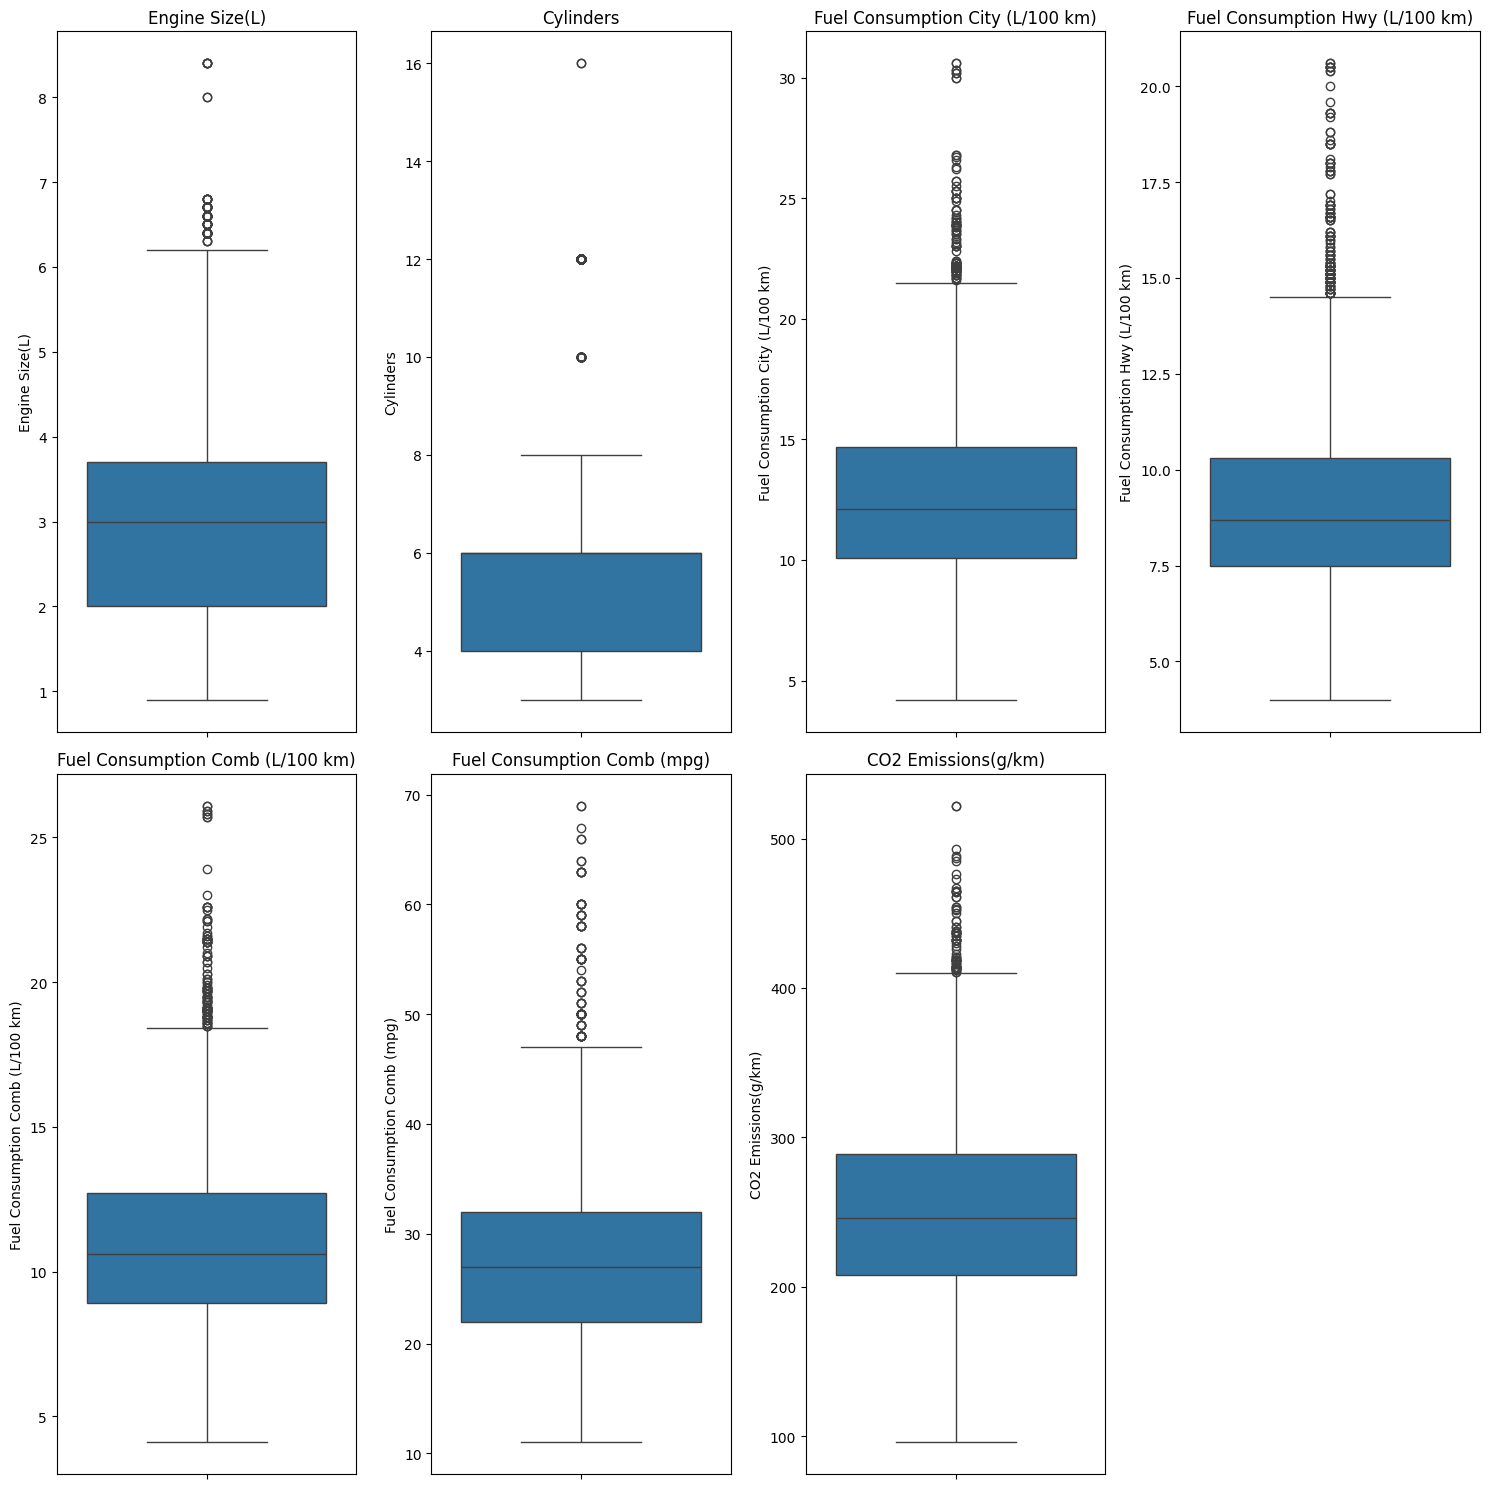

In [ ]:
plt.figure(figsize=(15, 15))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
outliers_summary = {}

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))]

    outliers_summary[column] = outliers

    print(f"Outlier ({column} in column):\n{outliers}\n")

    print(f"Total Outlier ({column} in column): {outliers.shape[0]}\n{'-'*50}\n")

Outlier (Engine Size(L) in column):
            Brand                 Model             Vehicle Class  \
36           AUDI                   A8L                 FULL-SIZE   
75        BENTLEY              MULSANNE                  MID-SIZE   
290      CHRYSLER         300 SRT (MDS)                 FULL-SIZE   
300         DODGE        CHALLENGER SRT                  MID-SIZE   
301         DODGE  CHALLENGER SRT (MDS)                  MID-SIZE   
...           ...                   ...                       ...   
7286  ROLLS-ROYCE  Cullinan Black Badge  STATION WAGON - MID-SIZE   
7287  ROLLS-ROYCE                  Dawn                   COMPACT   
7288  ROLLS-ROYCE                 Ghost                 FULL-SIZE   
7289  ROLLS-ROYCE             Ghost EWB                 FULL-SIZE   
7292  ROLLS-ROYCE                Wraith                  MID-SIZE   

      Engine Size(L)  Cylinders Transmission         Fuel Type  \
36               6.3         12          AS8  Premium Gasoline   
75 

In [ ]:
outlier_indices = set()

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))]
    outlier_indices.update(outliers.index)

# Drop all outliers at once
df = df.drop(index=outlier_indices)
df.reset_index(drop=True, inplace=True)
print(f"Cleaned data shape: {df.shape}")

Cleaned data shape: (5816, 12)


In [ ]:
lower_percentile = 0.01 # normalnya 1 vs 99 percentile, atau 5 vs 95
upper_percentile = 0.99

outlier_indices = set()

for column in numerical_columns:
    lower_bound = df[column].quantile(lower_percentile)
    upper_bound = df[column].quantile(upper_percentile)

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outlier_indices.update(outliers.index)

df = df.drop(index=outlier_indices)
df.reset_index(drop=True, inplace=True)

print(f"Cleaned data shape: {df.shape}")

Cleaned data shape: (5580, 12)


In [ ]:
z_scores = df[numerical_columns].apply(zscore)

# threshold bisa diturunin buat buang semua outlier, tapi lose some important data like max and min
threshold = 3
outlier_indices = (z_scores.abs() > threshold).any(axis=1)

df = df[~outlier_indices]
df.reset_index(drop=True, inplace=True)

print(f"Cleaned data shape: {df.shape}")

Cleaned data shape: (5565, 12)


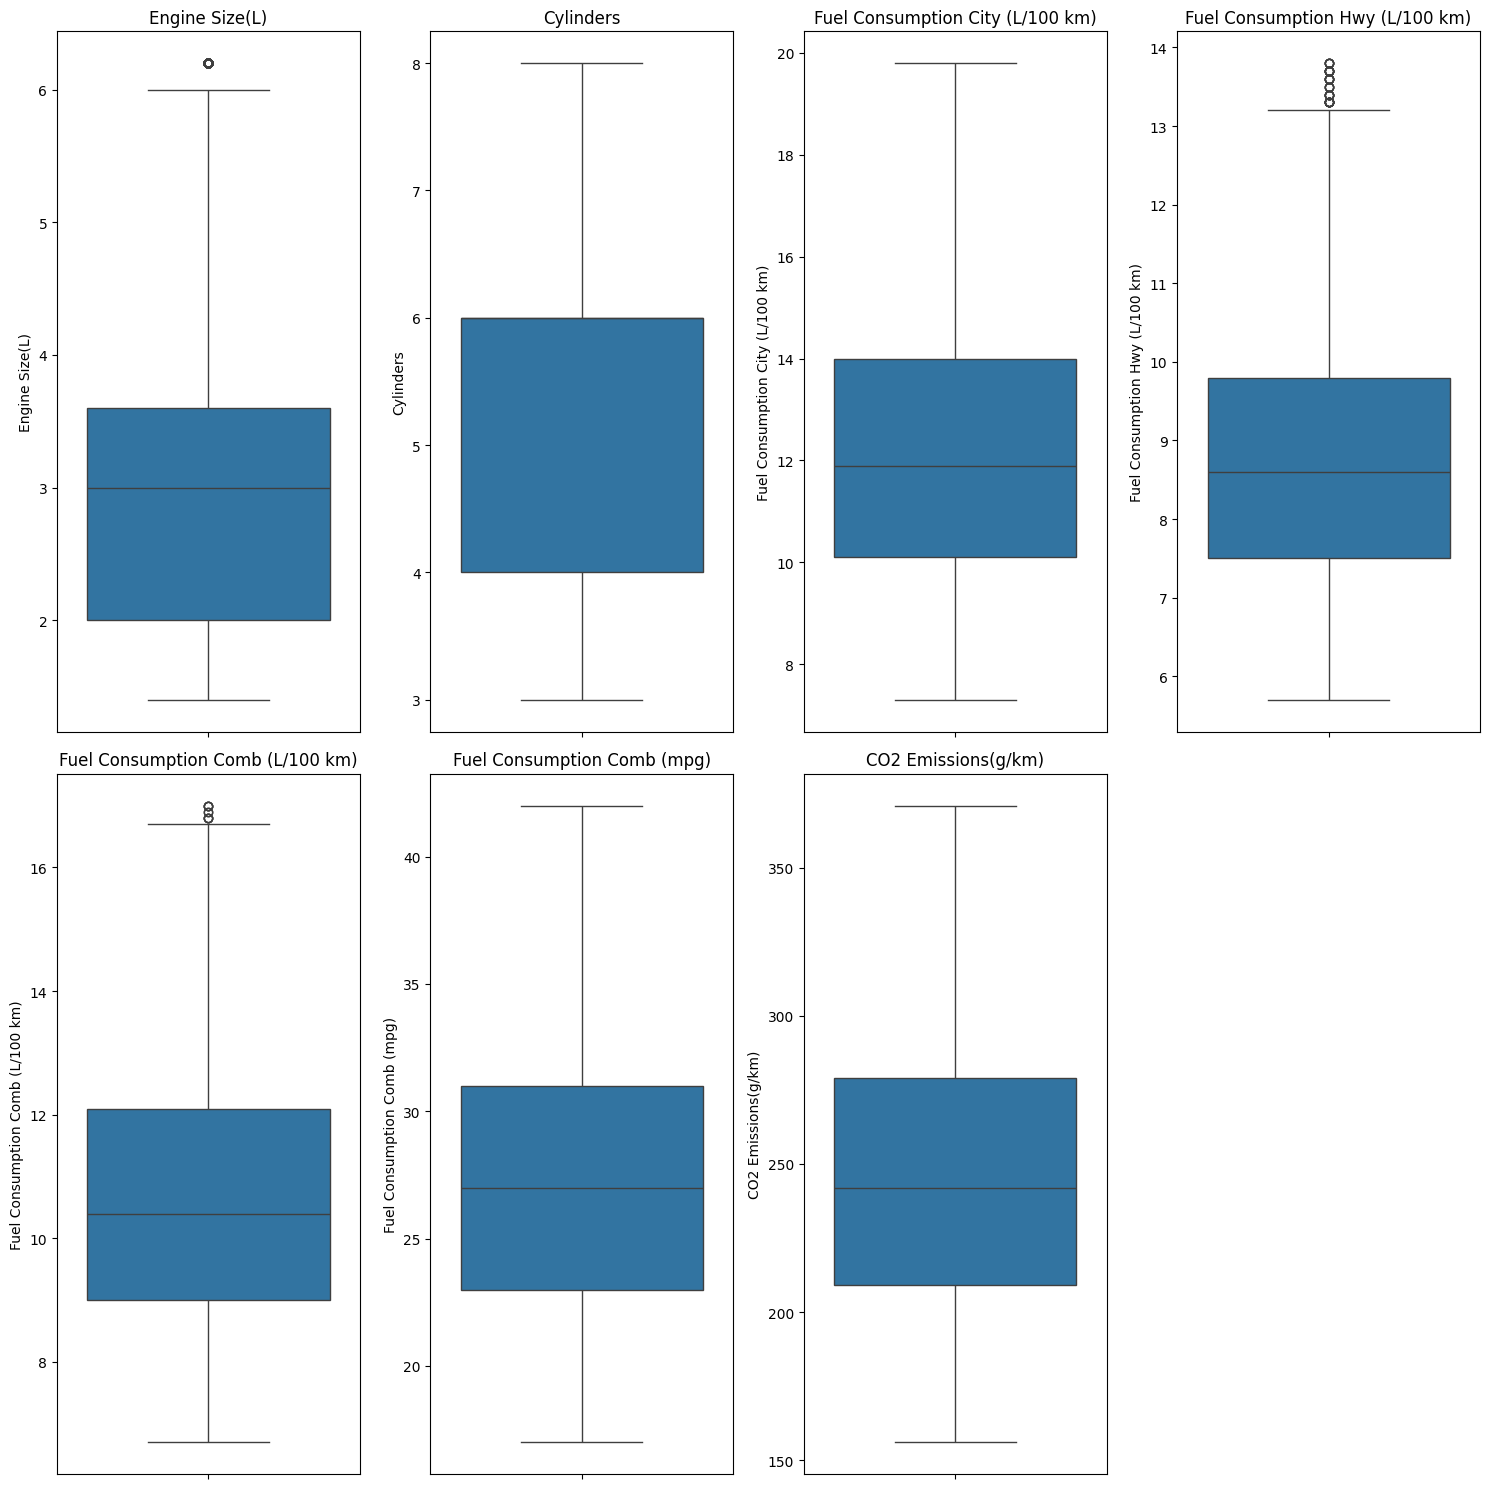

In [ ]:
plt.figure(figsize=(15, 15))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
df.isnull().sum()

,0
Brand,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


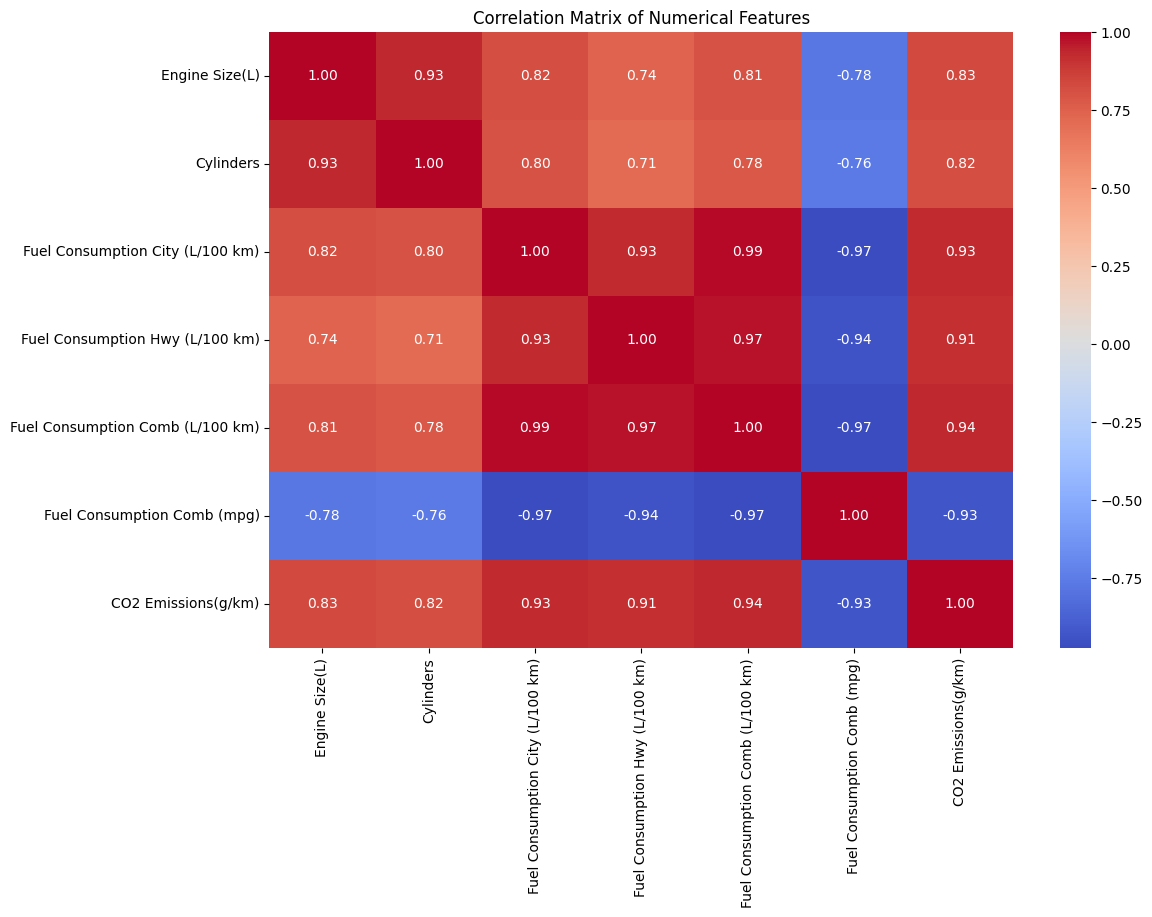

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df[numerical_columns].corr()

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
df = df.drop(['Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption City (L/100 km)'], axis=1)
df

,Brand,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Premium Gasoline,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Premium Gasoline,29,221
2,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Premium Gasoline,25,255
3,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Premium Gasoline,27,244
4,ACURA,RLX,MID-SIZE,3.5,6,AS6,Premium Gasoline,28,230
...,...,...,...,...,...,...,...,...,...
5560,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Premium Gasoline,30,219
5561,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Premium Gasoline,29,232
5562,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Premium Gasoline,27,240
5563,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Premium Gasoline,29,232


# Exploratory Data Analysis (EDA)

In [ ]:
# Filter only object (categorical) columns
categorical_cols = df.select_dtypes(include='object').columns

# Loop through and print unique values
for col in categorical_cols:
    print(f"\nUnique values in '{col}' ({df[col].nunique()}):")
    print(df[col].unique())


Unique values in 'Brand' (37):
['ACURA' 'ALFA ROMEO' 'ASTON MARTIN' 'AUDI' 'BENTLEY' 'BMW' 'BUICK'
 'CADILLAC' 'CHEVROLET' 'CHRYSLER' 'DODGE' 'FIAT' 'FORD' 'GMC' 'HONDA'
 'HYUNDAI' 'INFINITI' 'JAGUAR' 'JEEP' 'KIA' 'LAND ROVER' 'LEXUS' 'LINCOLN'
 'MASERATI' 'MAZDA' 'MERCEDES-BENZ' 'MINI' 'MITSUBISHI' 'NISSAN' 'PORSCHE'
 'RAM' 'SCION' 'SUBARU' 'TOYOTA' 'VOLKSWAGEN' 'VOLVO' 'GENESIS']

Unique values in 'Model' (1845):
['ILX' 'MDX 4WD' 'RDX AWD' ... 'Tacoma 4WD D-Cab TRD Off-Road/Pro'
 'Atlas Cross Sport 4MOTION' 'XC40 T4 AWD']

Unique values in 'Vehicle Class' (16):
['COMPACT' 'SUV - SMALL' 'MID-SIZE' 'TWO-SEATER' 'SUBCOMPACT' 'FULL-SIZE'
 'STATION WAGON - SMALL' 'SUV - STANDARD' 'VAN - CARGO'
 'PICKUP TRUCK - STANDARD' 'MINIVAN' 'MINICOMPACT'
 'SPECIAL PURPOSE VEHICLE' 'STATION WAGON - MID-SIZE'
 'PICKUP TRUCK - SMALL' 'VAN - PASSENGER']

Unique values in 'Transmission' (26):
['AS5' 'M6' 'AS6' 'AM6' 'AM7' 'AV8' 'AS8' 'A7' 'A6' 'A8' 'M7' 'A4' 'M5'
 'A5' 'AV' 'AV7' 'AS7' 'A9' 'AS9' 'AV6' 

In [ ]:
df.nunique()

,0
Brand,37
Model,1845
Vehicle Class,16
Engine Size(L),38
Cylinders,5
Transmission,26
Fuel Type,5
Fuel Consumption Comb (mpg),26
CO2 Emissions(g/km),215


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5565 entries, 0 to 5564
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Brand                        5565 non-null   object 
 1   Model                        5565 non-null   object 
 2   Vehicle Class                5565 non-null   object 
 3   Engine Size(L)               5565 non-null   float64
 4   Cylinders                    5565 non-null   int64  
 5   Transmission                 5565 non-null   object 
 6   Fuel Type                    5565 non-null   object 
 7   Fuel Consumption Comb (mpg)  5565 non-null   int64  
 8   CO2 Emissions(g/km)          5565 non-null   int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 391.4+ KB


In [ ]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,5565.000000,5565.000000,5565.000000,5565.000000
mean,2.994034,5.373226,27.625517,245.829829
std,1.175685,1.485117,5.523878,47.478888
min,1.400000,3.000000,17.000000,156.000000
25%,2.000000,4.000000,23.000000,209.000000
50%,3.000000,6.000000,27.000000,242.000000
75%,3.600000,6.000000,31.000000,279.000000
max,6.200000,8.000000,42.000000,371.000000


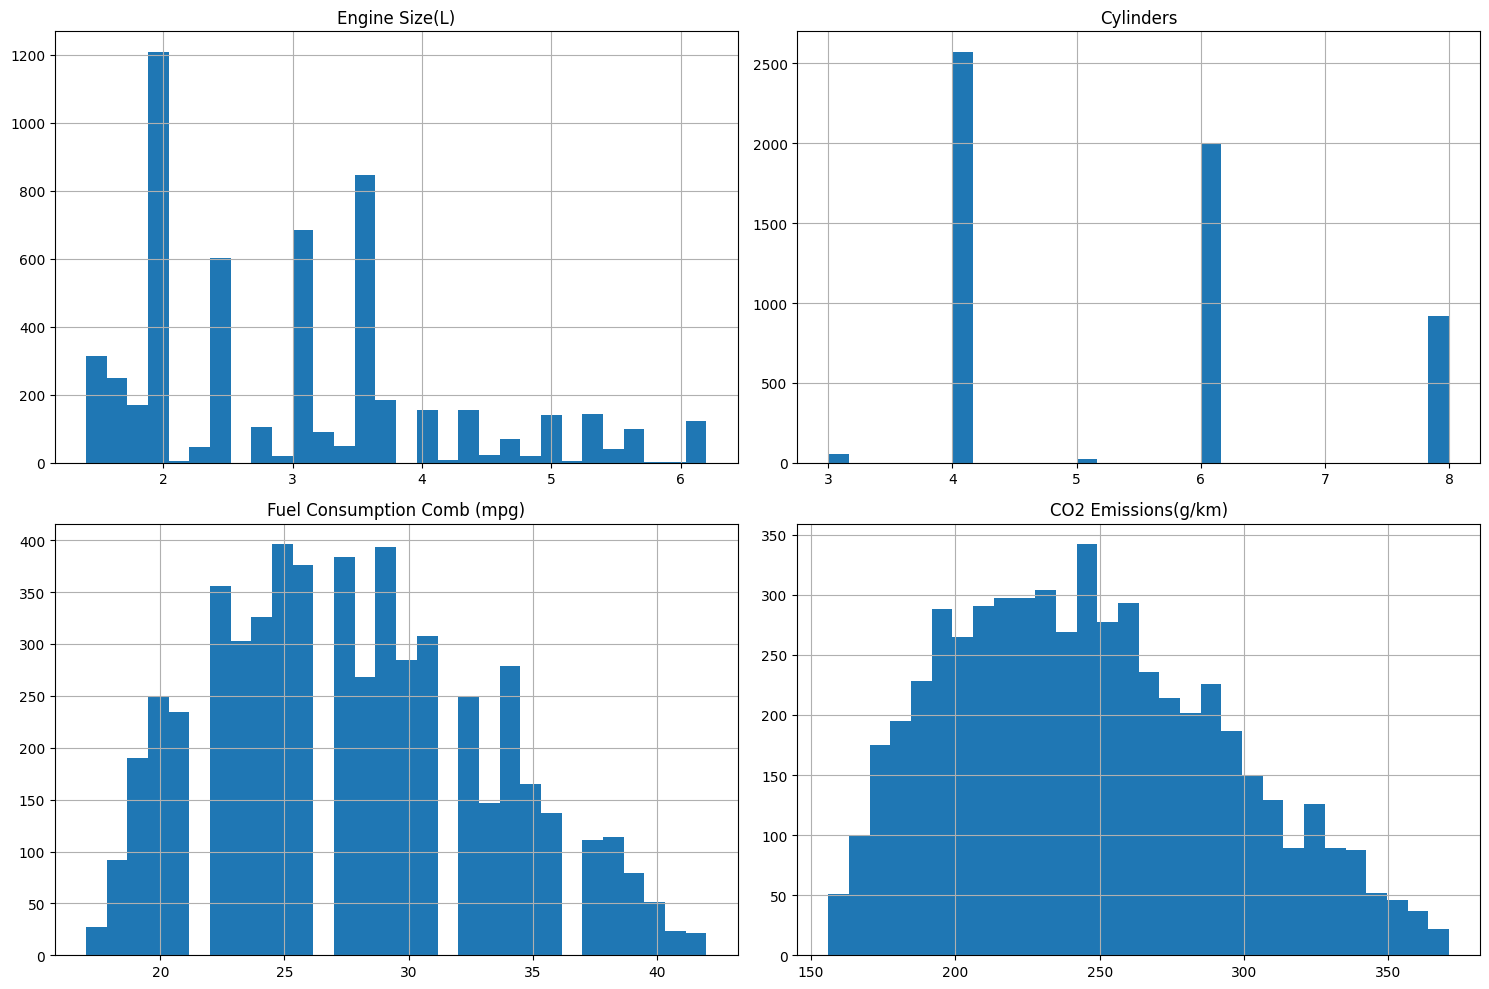

In [ ]:
df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

1. Engine Size

  - Menggambarkan distribusi kapasitas mesin dalam satuan liter.

  - Mayoritas kendaraan memiliki mesin berkapasitas antara 2.0 hingga 3.5 liter.

  - Mesin kecil 1.5L dan besar >5L jarang memiliki pengguna. Lebih sering ditemukan 2-3 liter

2. Cylinders

  - Menggambarkan jumlah silinder mesin.

  - Kebanyakan kendaraan memiliki 4 atau 6 silinder.

  - Jumlah kendaraan dengan 8 silinder juga luamayan ada pengguna.

  - Jumlah kendaraan dengan 3 dan 5 silinder memiliki pengguna yang sedikit

3. Fuel Consumption City

  - Menggambarkan Konsumsi bahan bakar di dalam kota.

  - Banyak kendaraan mengonsumsi antara 8 hingga 14 L per 100 km.

  - Tetapi kendaraan sangat boros yaitu dengan konumsi bahan bakarmendekati 20 L/100 km.

4. Fuel Consumption Hwy

  - Menggambarkan Konsumsi bahan bakar di jalan raya.

  - Kebanyakan kendaraan hemat bahan bakar di jalan raya, berkisar 6–10 L/100 km.

5. Fuel Consumption Comb
  - Menggabarkan Konsumsi bahan bakar kombinasi (gabungan kota dan jalan raya).

  - Distribusinya mirip dengan konsumsi di kota dan jalan raya, dengan puncak sekitar 9-11 L/100 km.

6. Fuel Consumption Comb

  - Menggambarkan Konsumsi bahan bakar kombinasi dalam satuan miles per gallon (mpg).

  - Nilai mpg berbanding terbalik dengan liter per 100 km: semakin tinggi mpg, semakin hemat.

  - Paling banyak kendaraan mengonsumsi bahan bajar berada di kisaran 25-30 mpg.

7. CO2 Emissions

  - Menggambarkan Emisi karbon dioksida kendaraan.

  - Distribusinya mendekati normal dengan puncak sekitar 230-250 g/km.

  - Beberapa kendaraan sangat ramah lingkungan (150 g/km), sementara yang lain sangat tinggi (mendekati 400 g/km).

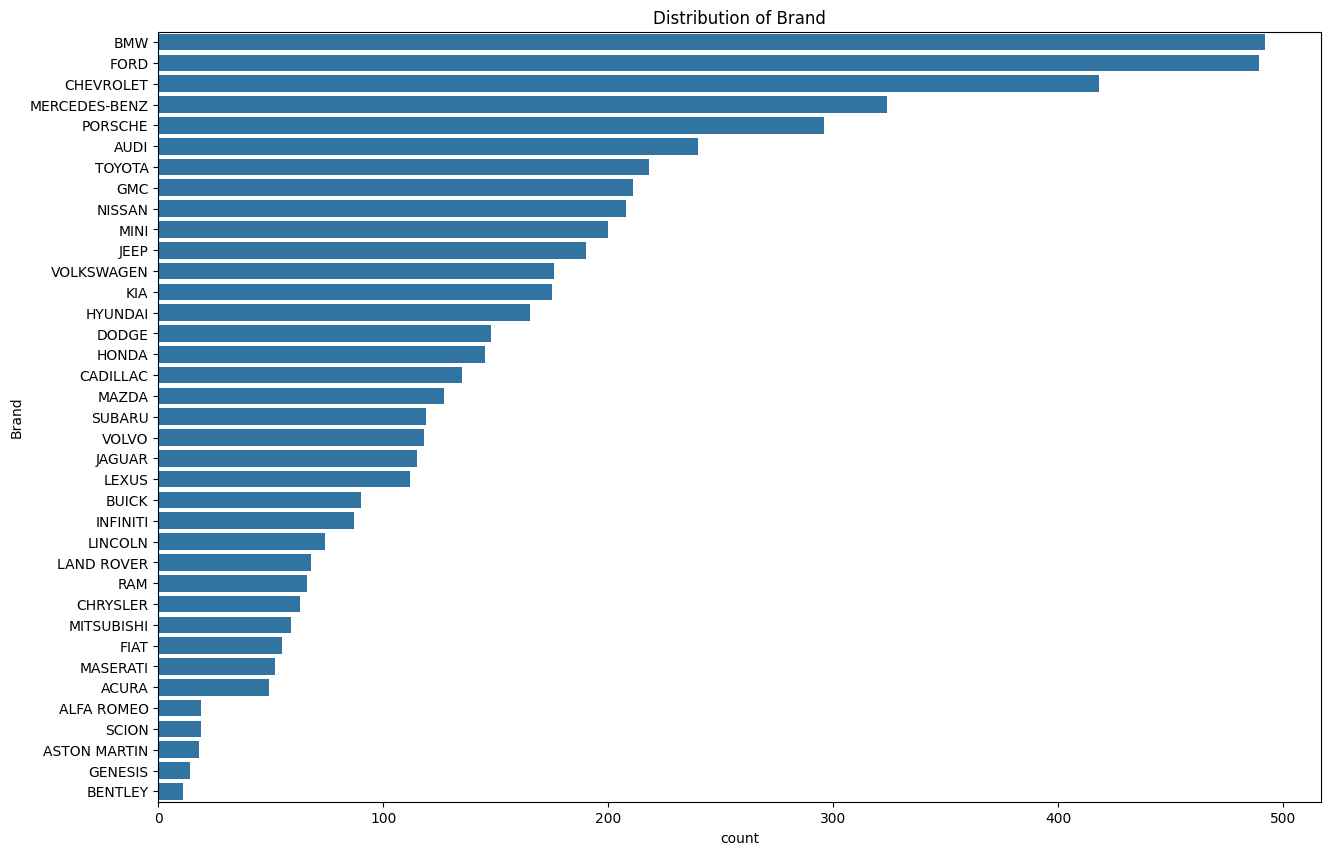

In [ ]:
plt.figure(figsize=(15, 10))
sns.countplot(y='Brand', data=df, order=df['Brand'].value_counts().index)
plt.title('Distribution of Brand')
plt.show()

## Distribusi Merek Kendaraan
- Grafik ini menunjukkan jumlah kendaraan dari berbagai merek dalam dataset.

- Ford, Chevrolet, BMW, dan Mercedes-Benz adalah merek kendaraan paling banyak sering ditemukan di dalam dataset.

- Porsche, Toyota, dan GMC juga termasuk merek yang lumayan sering ditemukan pada dataset.

- Merek-merek performa tinggi (Luxury car) seperti Bentley, aston martin, genesin, dan Lamborghini memiliki jumlah pengguna yang kecil.

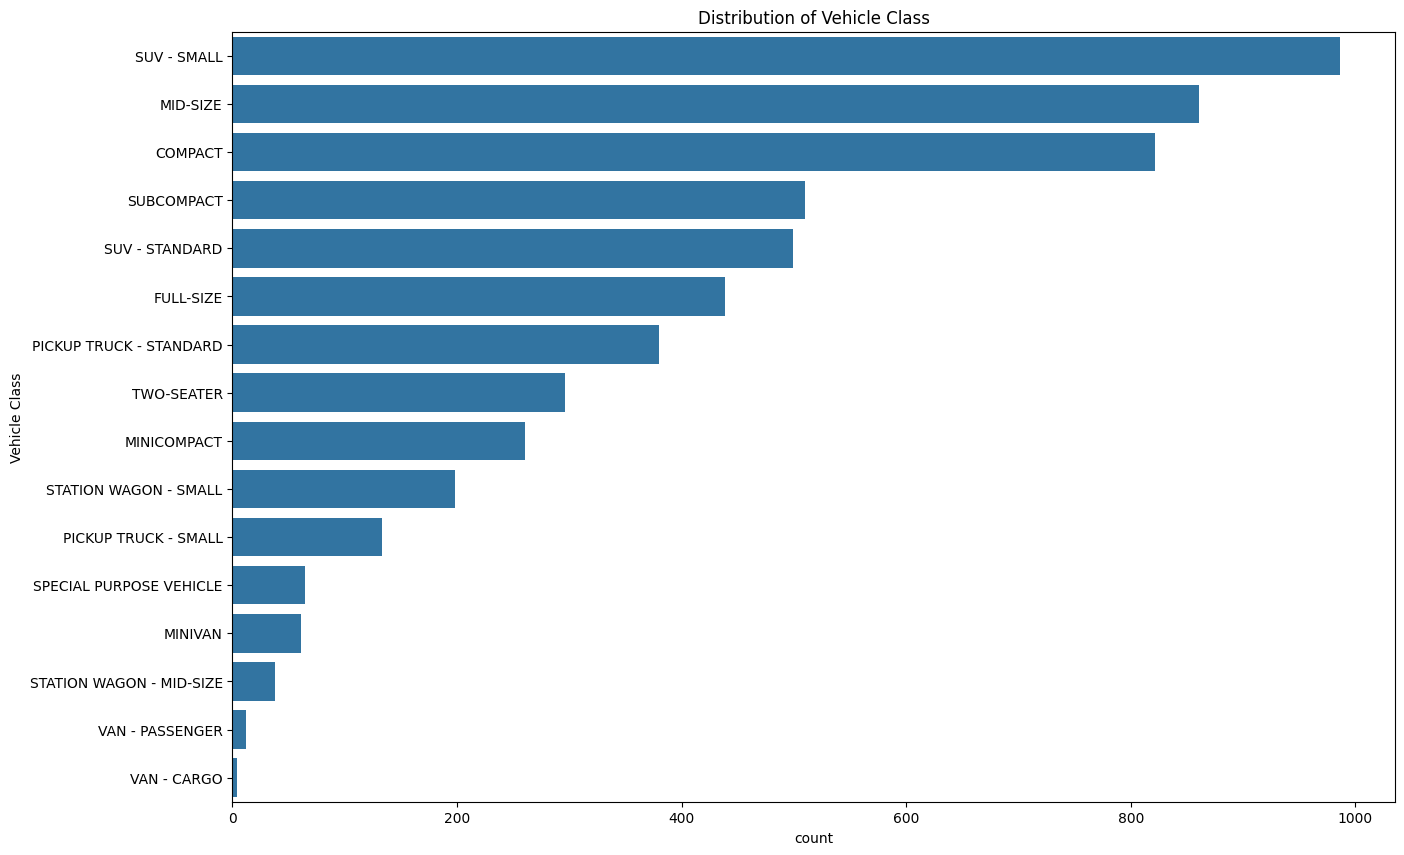

In [ ]:
plt.figure(figsize=(15, 10))
sns.countplot(y='Vehicle Class', data=df, order=df['Vehicle Class'].value_counts().index)
plt.title('Distribution of Vehicle Class')
plt.show()

## Distribusi Kelas Kendaraan
- Grafik distribusi kelas kendaraan ditunjukkan dalam grafik *Horizontal Bar Chart*, dengan sumbu Y menyatakan jenis kendaraannya, sedangkan sumbu X menyatakan jumlah kendaraan berdasarkan jenis kendaraannya.

- Alasan menggunakan Bar Chart karena data yang ditunjukkan berupa kategori yang bersifat diskrit, sehingga lebih cocok daripada menggunakan grafik lain seperti histogram ataupun scatter plot.

- Kelas kendaraan yang paling banyak digunakan adalah SUV - SMALL dengan jumlahnya mendekati 1200. Begitupun dengan MID-SIZE dan COMPACT sehingga hal ini menunjukkan bahwa jumlah kendaraan berukuran kecil dan menengah adalah yang paling banyak pada dataset ini.

- Jenis kendaraan lain yang cukup sering digunakan adalah SUV - STANDARD, SUBCOMPACT dan FULL SIZE.

- Kelas kendaraan seperti VAN - PASSENGER dan VAN - CARGO sangat jarang digunakan berdasarkan dataset ini. Ada beberapa alasan yang mungkin menjadi penyebab, seperti mahalnya biaya perawatan, pajak, keterbatasan infrasturktur yang mendukung, dan lain sebagainya.



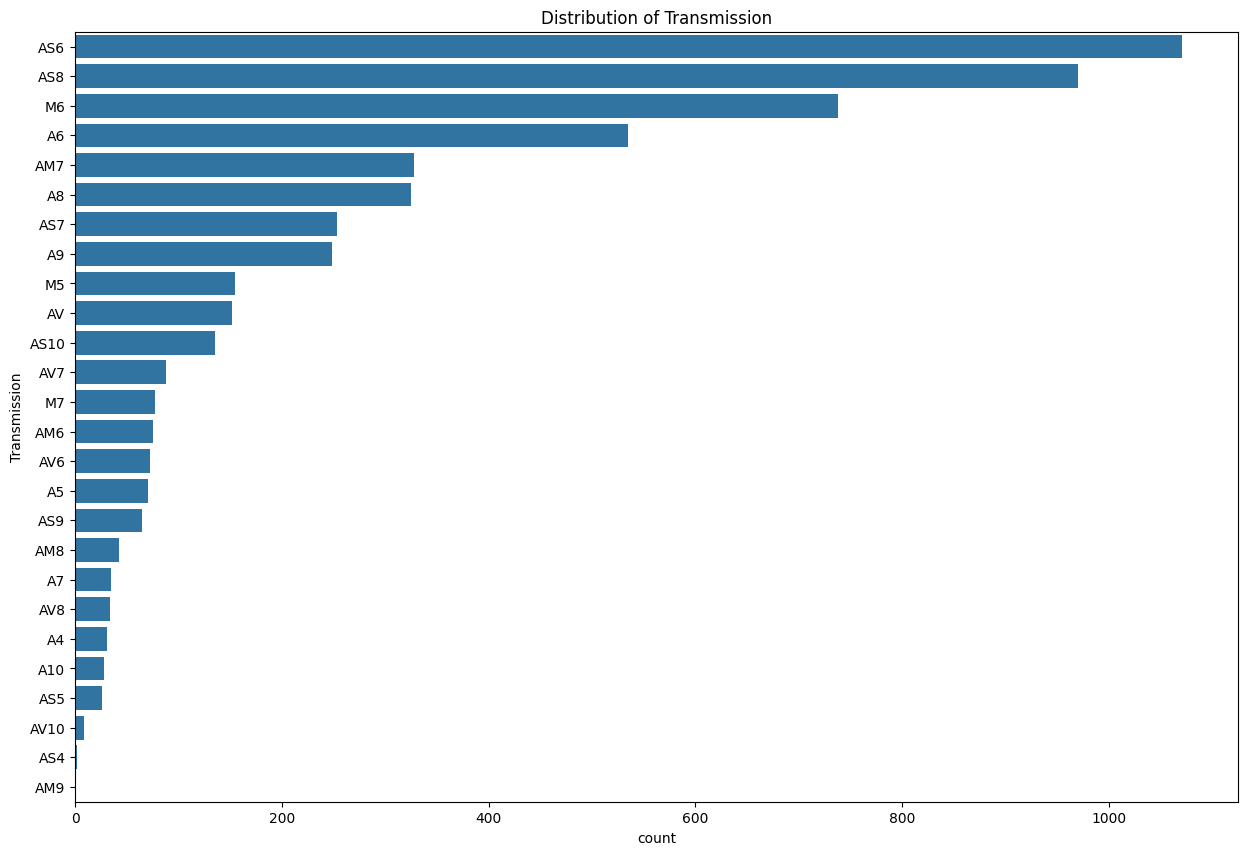

In [ ]:
plt.figure(figsize=(15, 10))
sns.countplot(y='Transmission', data=df, order=df['Transmission'].value_counts().index)
plt.title('Distribution of Transmission')
plt.show()

## Distribusi Transmisi

- Jenis transmisi yang paling umum digunakan pada kendaraan selama di data adalah AS6, AS8, dan M6.

- Transmisi lainnya seperti A6, A8, AM7, dan A9 lumayan sering digunakan oleh kendaraan.

- Transmisi seperti AS4, AM9, dan AM5 sangat jarang digunakan oleh kendaraan yang terdapat pada data.

- Perubahan tren distrubusi transmisi terjadi karena evolusi penggunaan kendaraan, perkembangan jumlah rasio gigi, perubahan teknologi, dan sebagainya.

<table>
  <tr>
    <th>AS6</th>
    <th>AS8</th>
    <th>M6</th>
  </tr>
  <tr>
    <td>
      <img src="https://www.christiani-international.com/out/pictures/generated/product/1/665_665_75/98343-6-speed-manual-transmission-zf.jpg" width="250">
    </td>
    <td>
      <img src="https://raw.githubusercontent.com/bryanherdianto/vehicle_co2_analysis/refs/heads/main/assets/9hp_geschlossen_neu_71957.png" width="250">
    </td>
    <td>
      <img src="https://i.ebayimg.com/images/g/JPsAAOSwmBtmnHrT/s-l400.png" width="250">
    </td>
  </tr>
</table>

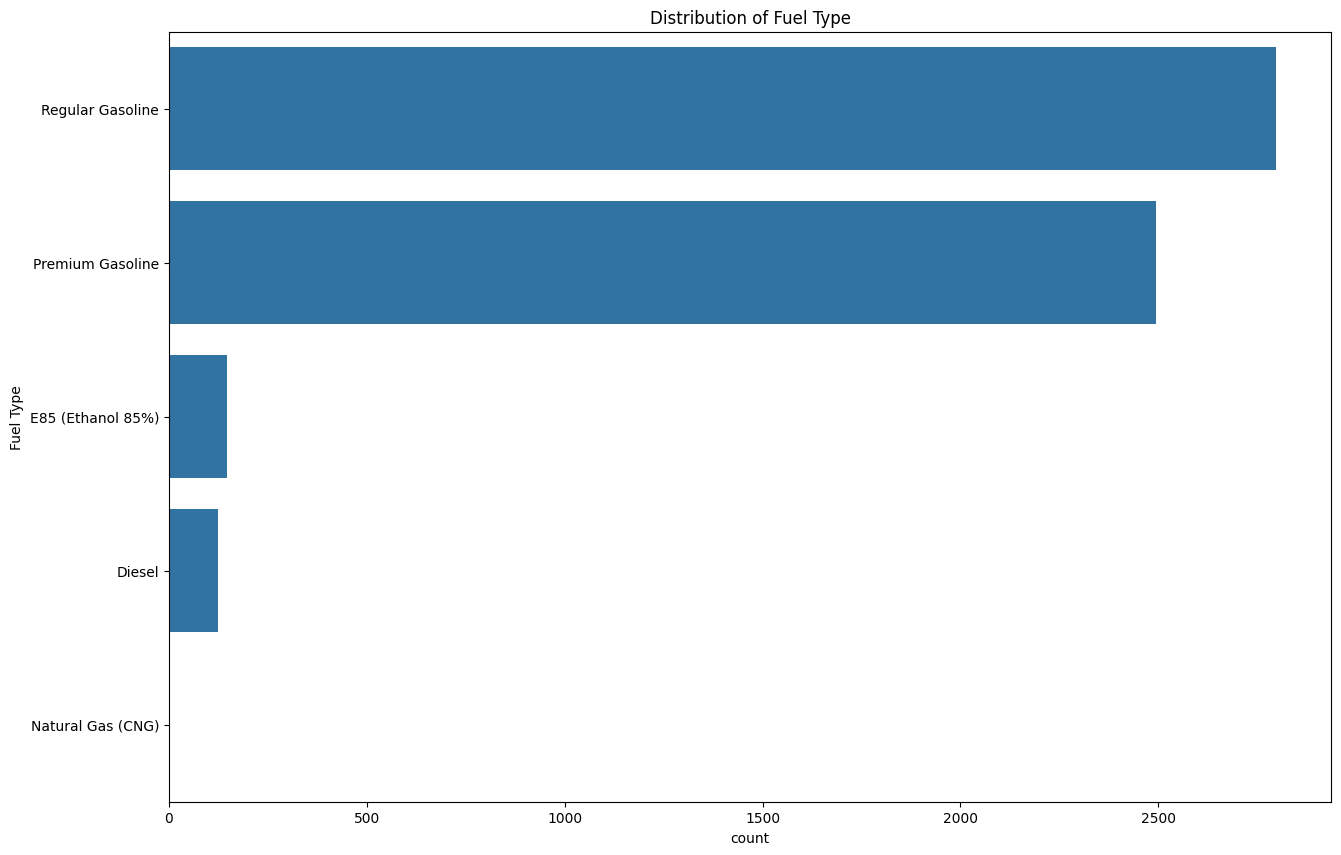

In [ ]:
plt.figure(figsize=(15, 10))
sns.countplot(y='Fuel Type', data=df, order=df['Fuel Type'].value_counts().index)
plt.title('Distribution of Fuel Type')
plt.show()

## Distribusi Jenis Bahan Bakar Kendaraan

- Jenis bahan bakar regular gasoline dan premium gasoline adalah yang paling banyak digunakan oleh kendaraan dalam data ini. Namun, lebih banyak digunakan bahan bakar regular gasoline.

- Jenis bahan bakar E85 dan Diesel hanya digunakan pada beberapa mobil.

- Jenis bahan bakar Natural gas (hampir) tidak ada yang menggunakan



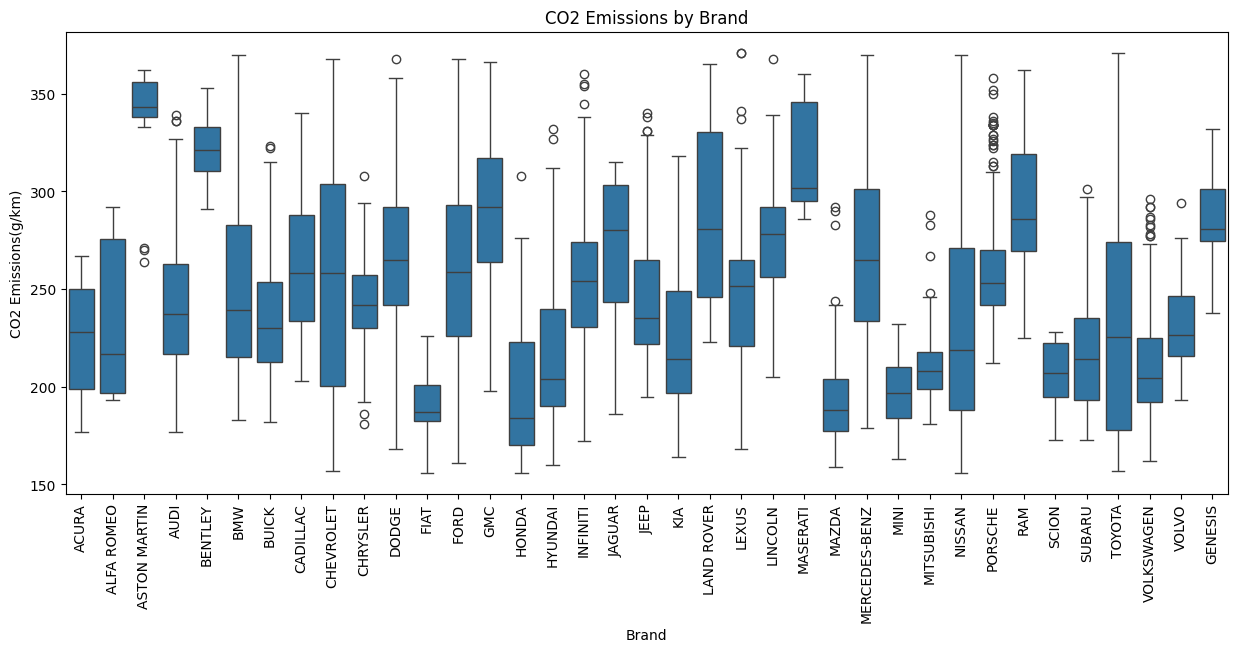

In [ ]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='Brand', y='CO2 Emissions(g/km)', data=df)
plt.xticks(rotation=90)
plt.title('CO2 Emissions by Brand')
plt.show()

## Distribusi Emisi CO₂ per Merek Kendaraan

- Merek seperti Lamborghini, Bently, Maserati, dan Aston Martin memiliki emisi CO₂ yang sangat tinggi. Hal tersebut terjadi karena mobil-mobil tersebur termasuk dalam luxury car dan memiliki bertenaga besar

- Merek seperti Mazda, Fiat, dan Mini memiliki emisi yang rendah

- Toyota, Nissan, Ford, GMC, dan RAM cenderung memiliki variasi emisi yang luas, dengan banyak kendaraan mereka yang berkontribusi pada emisi karbon yang rendah hingga tinggi.

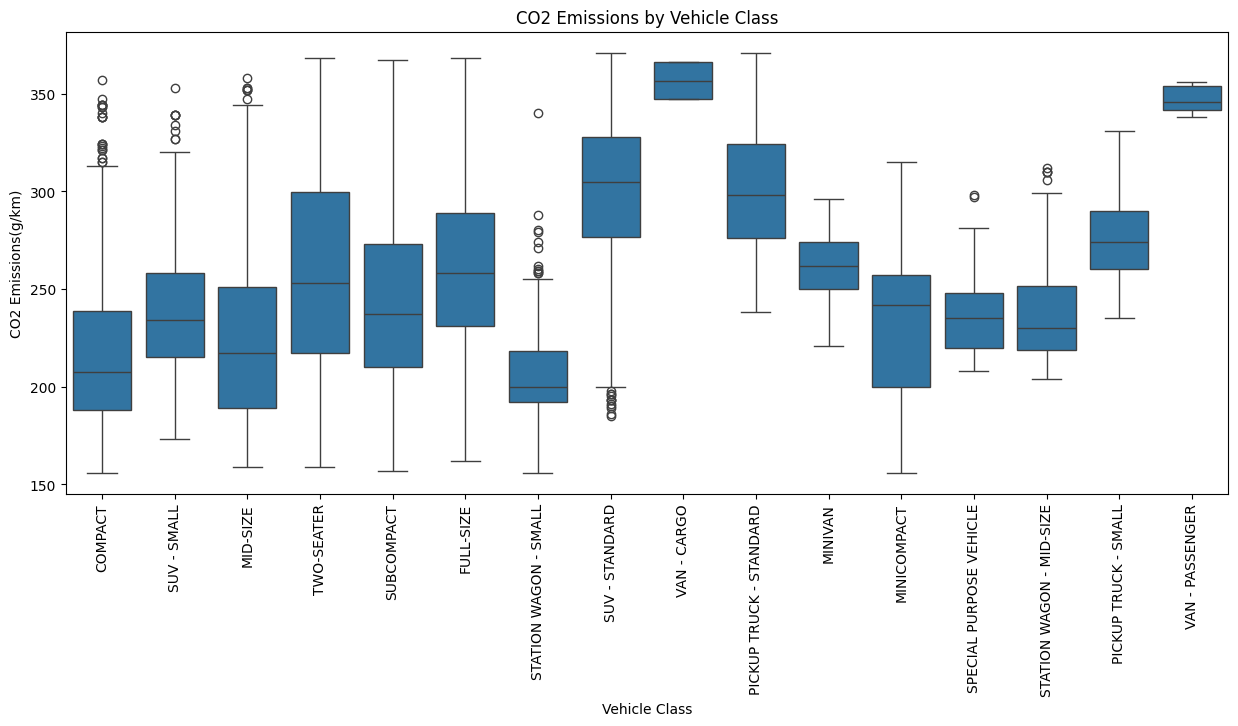

In [ ]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='Vehicle Class', y='CO2 Emissions(g/km)', data=df)
plt.xticks(rotation=90)
plt.title('CO2 Emissions by Vehicle Class')
plt.show()

## Distribusi Emisi CO₂ per Kelas Kendaraan

- Kendaraan dengan kelas Full Size, SUV Standard, dan Pickup Truck  Standard cenderung memiliki emisi CO₂ yang tinggi.

- Kendaraan berukuran besar umumnya menghasilkan banyak emisi. Sedangkan, kelas Compact, Station Wagon Small, dan Minivan memiliki emisi yang rendah.

- Beberapa kelas seperti SUV Small dan Mid Size menunjukkan emisi yang cukup besar.

- Pada kelas Subcompact teradapat beberapa kendaraan yang emisinya lebih tinggi dari rata-rata.

- Kendaraan yang lebih kecil cenderung menghasilkan lebih sedikit emisi CO₂ dibandingkan kendaraan besar.

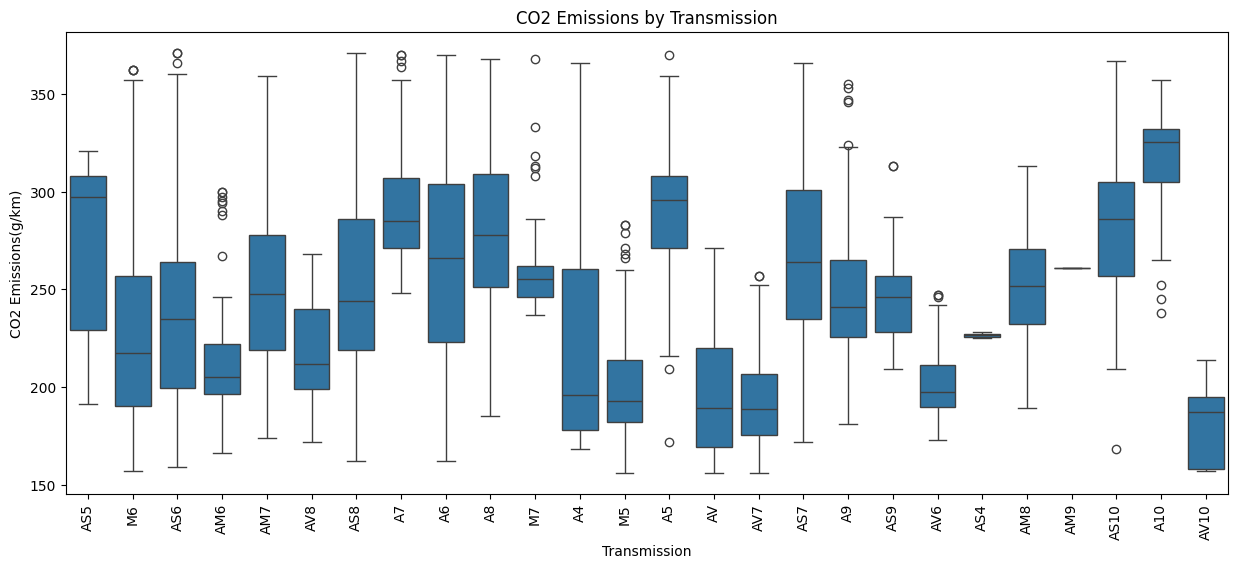

In [ ]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='Transmission', y='CO2 Emissions(g/km)', data=df)
plt.xticks(rotation=90)
plt.title('CO2 Emissions by Transmission')
plt.show()

## Distribusi Emisi CO₂ per Jenis Transmisi

- Transmisi AV dan manual cenderung lebih efisien dalam hal emisi CO₂.

- Semakin tinggi angka di belakang huruf "A", biasanya emisi juga lebih tinggi

- Beberapa transmisi manual menunjukkan emisi lebih rendah dan stabil.

Keterangan:  
A = Automatic; AM = Automated manual; AS = Automatic with select shift; AV = Continuously variable; M = Manual; Number of gears/speeds (1-10)  

Referensi:  
https://natural-resources.canada.ca/energy-efficiency/transportation-energy-efficiency/personal-vehicles/understanding-tables

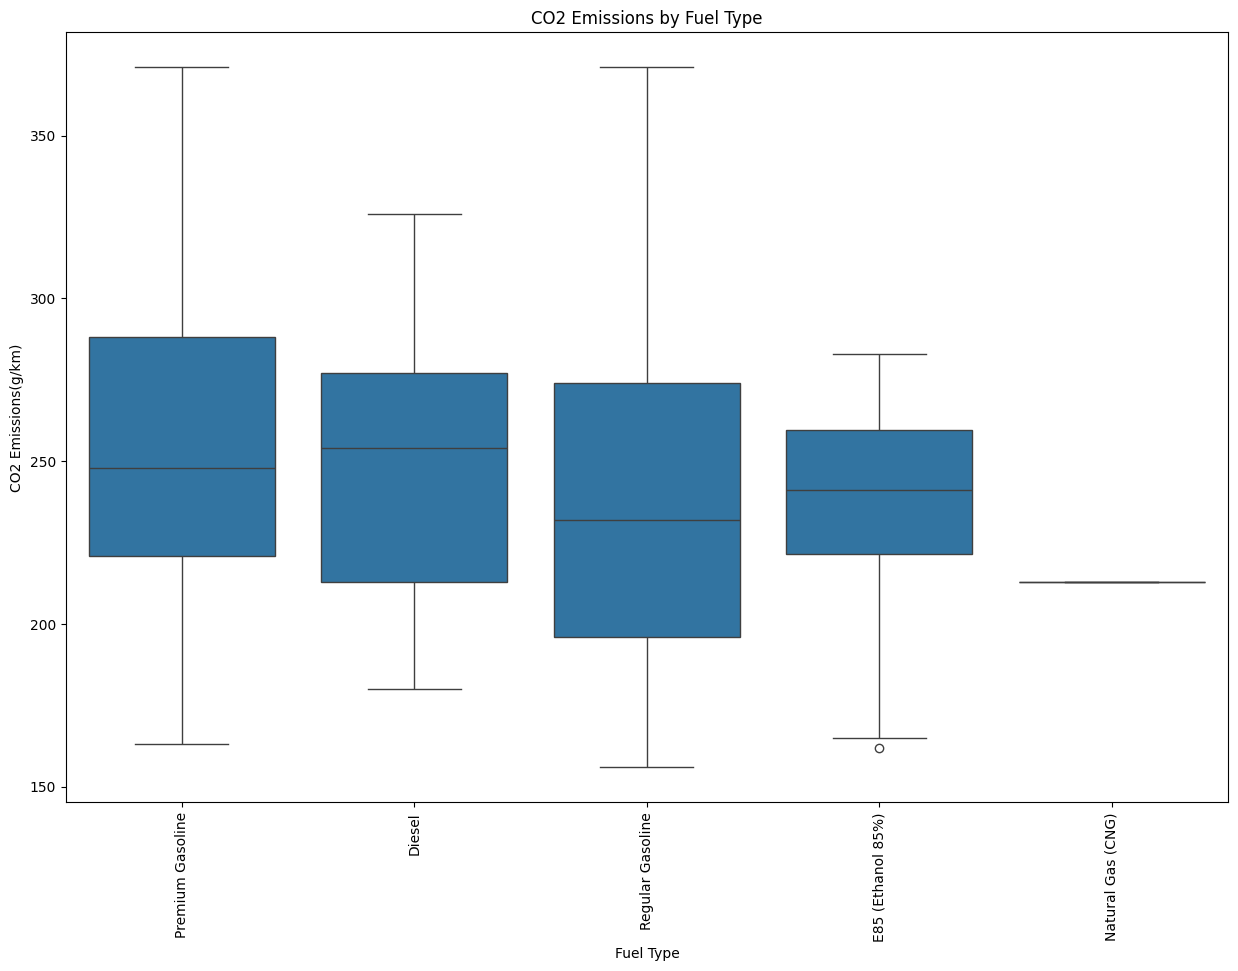

In [ ]:
plt.figure(figsize=(15, 10))
sns.boxplot(x='Fuel Type', y='CO2 Emissions(g/km)', data=df)
plt.xticks(rotation=90)
plt.title('CO2 Emissions by Fuel Type')
plt.show()

## Distribusi Emisi CO₂ berdasarkan Fuel Type
- Premium Gasoline = Memiliki emisi CO₂ tertinggi dan paling bervariasi

- Diesel = Emisi lebih stabil dan sedikit lebih rendah dari Premium Gasoline

- Regular Gasoline = Emisi sedang, tetapi variasi besar

- E85 = Median tinggi, tapi memiliki variasi hingga emisi rendah

- Natural Gas = Emisinya seragam dan rendah karena hanya ada 1-2 kendaraan

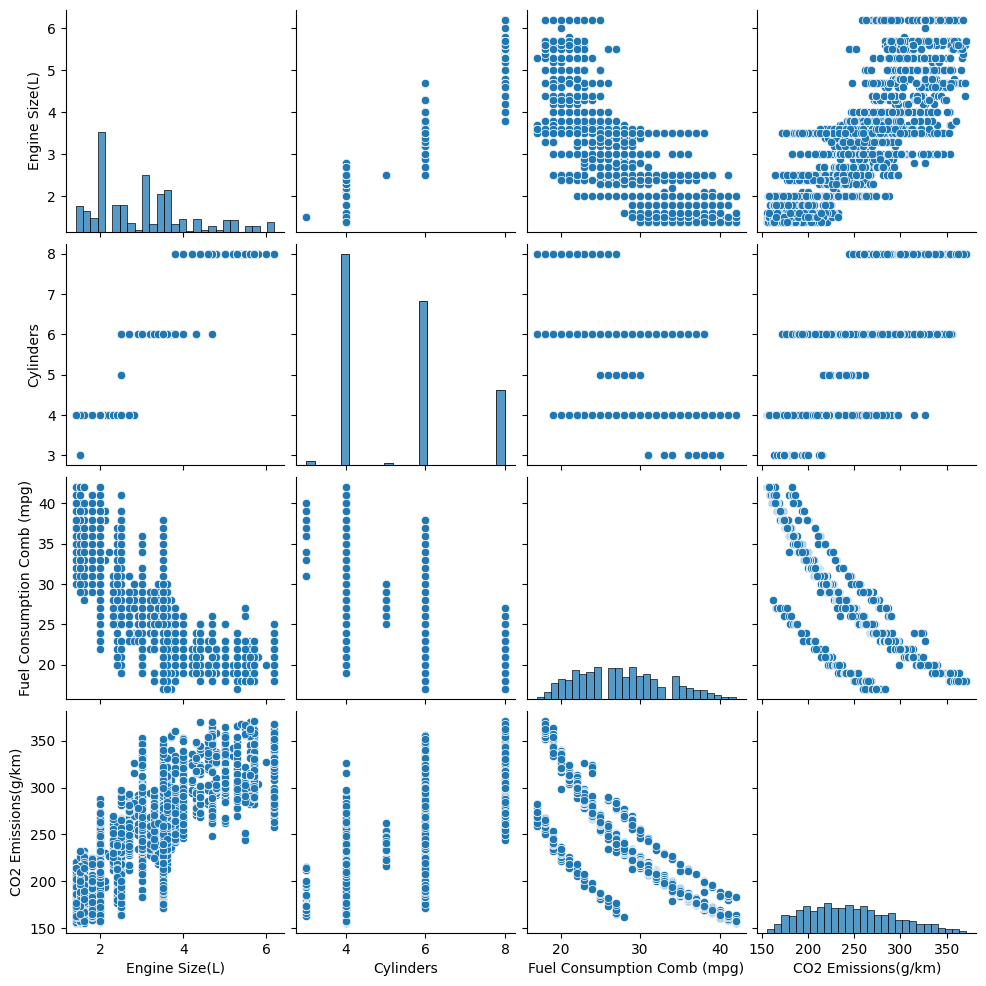

In [ ]:
sns.pairplot(df[['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']])
plt.show()

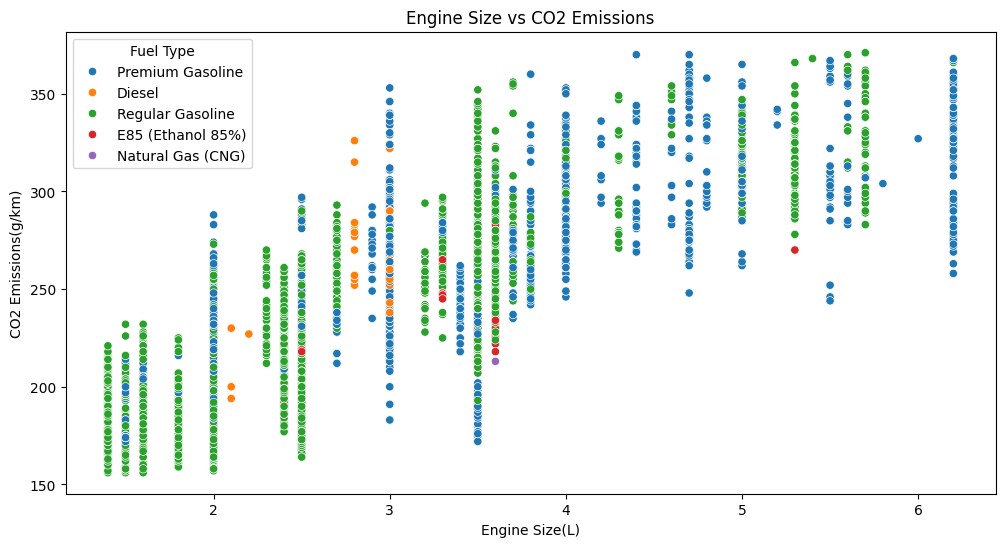

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Engine Size(L)', y='CO2 Emissions(g/km)', hue='Fuel Type', data=df)
plt.title('Engine Size vs CO2 Emissions')
plt.show()

## Grafik Hubungan antara ukuran mesin dengan emisi CO₂
Semakin besar ukuran mesin maka semakin tinggi emisi CO₂ yang dihasilkan, karena semakin besar mesin maka yang memerlukan lebih banyak bahan bakar.

Pada ukuran mesin yang sama jika kendaraan tersebut menggunakan bahan bakar ethanol dan natural gas kendaraan tersebut menghasilkan emisi CO₂ yang lebih rendah dibandingkan kendaraan yang menggunakan bahan bakar diesel dan bensin.



<!-- ## Grafik 2 (Hubungan konsumsi bahan bakar gabungan dengan emisi CO₂)
Jika kendaraan semakin banyak menggunakan bahan bakar maka semakian tinggi juga tingkat emisi CO₂ yang dihasilkan.

Bahan bakar diesel memiliki emisi CO₂ yang lebih tinggi dibandingkan dengan bensin untuk tingkat konsumsi bahan bakar yang sama.

Bahan Bakar ethanol menghasilkan emisi CO₂ yang lebih rendah walaupun konsumsi bahan bakarnya tinggi. -->


# <div style="text-align:center; padding:15px; color:white; margin:0; font-size:150%; font-family:'Times New Roman'; background-color:#FF7D33   ; overflow:hidden"><b>Model</b></div>

In [ ]:
X = df.drop('CO2 Emissions(g/km)', axis=1)
y = df['CO2 Emissions(g/km)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

numeric_features = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (mpg)']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Brand', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [ ]:
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor', LinearRegression())])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R^2 Score: {r2:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

Mean Absolute Error: 4.36
R^2 Score: 0.98
Root Mean Squared Error: 6.07


In [ ]:
regressor = model.named_steps['regressor']

feature_names = numeric_features + list(model.named_steps['preprocessor']
                                        .transformers_[1][1]
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': regressor.coef_
})

intercept = regressor.intercept_

print("Regression Coefficients:")
print(coefficients)
print(f"\nIntercept: {intercept}")

Regression Coefficients:
                          Feature  Coefficient
0                  Engine Size(L)     7.730153
1                       Cylinders     1.088904
2     Fuel Consumption Comb (mpg)   -37.958423
3                     Brand_ACURA   -10.806879
4                Brand_ALFA ROMEO     2.199804
...                           ...          ...
1775             Fuel Type_Diesel    46.964910
1776  Fuel Type_E85 (Ethanol 85%)   -39.756767
1777  Fuel Type_Natural Gas (CNG)   -52.132326
1778   Fuel Type_Premium Gasoline    24.297154
1779   Fuel Type_Regular Gasoline    20.627029

[1780 rows x 2 columns]

Intercept: 231.01833466511562


In [ ]:
# Find the row with the maximum absolute coefficient
max_row = coefficients.loc[coefficients['Coefficient'].abs().idxmax()]

# Extract the feature and the coefficient
max_feature = max_row['Feature']
max_coefficient = max_row['Coefficient']

print("Feature with max absolute coefficient:", max_feature)
print("Coefficient value:", max_coefficient)

Feature with max absolute coefficient: Fuel Type_Natural Gas (CNG)
Coefficient value: -52.132326326321696


                            Feature  Coefficient
1777    Fuel Type_Natural Gas (CNG)   -52.132326
315   Model_AMG GLC 43 4MATIC COUPE    49.932521
1775               Fuel Type_Diesel    46.964910
1776    Fuel Type_E85 (Ethanol 85%)   -39.756767
984                    Model_LX 570    38.948377
1624         Model_X4 M Competition    38.398008
1617         Model_X3 M Competition    38.398008
1623                     Model_X4 M    38.398008
1616                     Model_X3 M    38.398008
223             Model_911 Speedster    38.159466


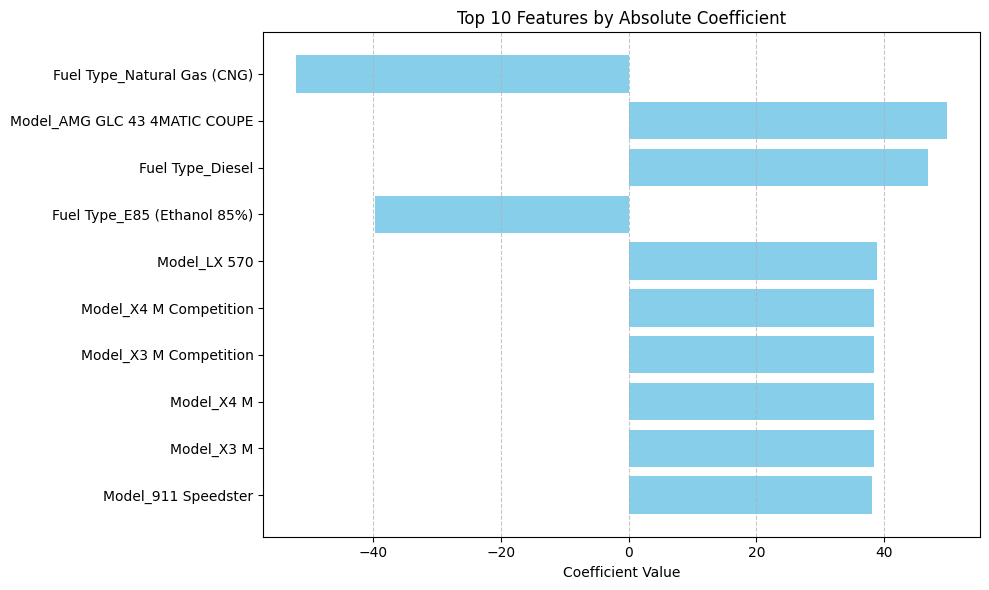

In [ ]:
# Sort the DataFrame by absolute coefficient values
top_10 = coefficients.reindex(coefficients['Coefficient'].abs().sort_values(ascending=False).index).head(10)

# Display the top 10 features
print(top_10)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(top_10['Feature'], top_10['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Top 10 Features by Absolute Coefficient')
plt.gca().invert_yaxis()  # Largest at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

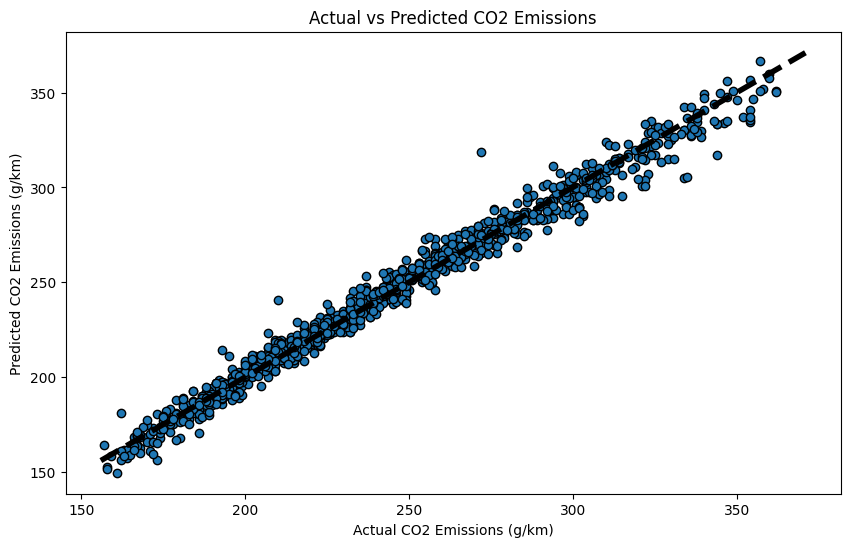

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, edgecolors=(0, 0, 0))
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
plt.xlabel('Actual CO2 Emissions (g/km)')
plt.ylabel('Predicted CO2 Emissions (g/km)')
plt.title('Actual vs Predicted CO2 Emissions')
plt.show()

## Grafik Regresi
Grafik di atas menunjukkan regresi antara Actual CO₂ Emission dalam g/km dengan hasil Predicted CO₂ Emissions dalam g/km. Setiap titik biru mewakili satu data kendaraan, di mana sumbu-x menampilkan nilai aktual dari dataset, sedangkan sumbu-y menunjukkan hasil prediksi dari model.

Garis putus-putus hitam menggambarkan prediksi sempurna, yaitu saat nilai prediksi sama persis dengan nilai aktual y = x. Jika semua titik berada tepat di garis ini, berarti model memprediksi dengan sangat tepat.

Bisa dilihat bahwa sebagian besar titik biru atau kendaraan berada sangat dekat dengan garis diagonal, menandakan bahwa model melakukan prediksi dengan cukup baik.

Terlihat juga beberapa titik yang berada agak jauh dari garis, ini mungkin menandakan ketidakakuratan model karena seharusnya semua outlier telah dibuang pada tahap sebelumnya.

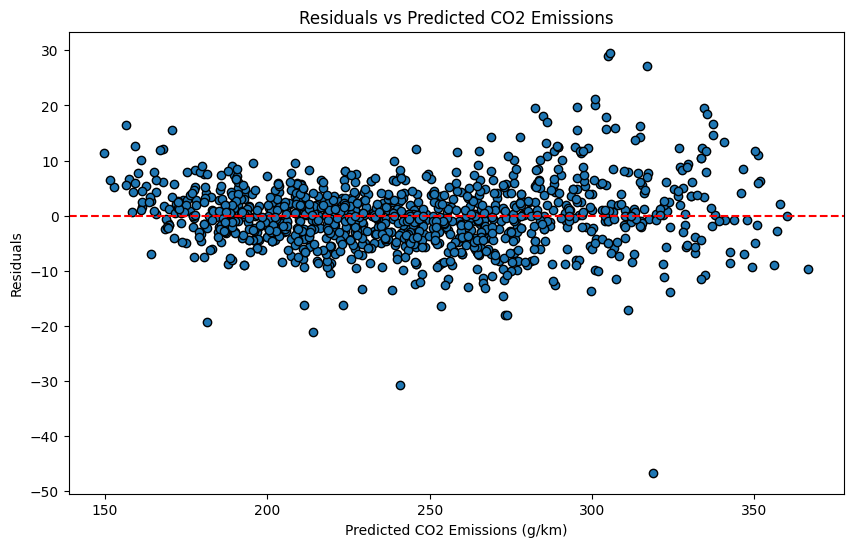

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, edgecolors=(0, 0, 0))
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted CO2 Emissions (g/km)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted CO2 Emissions')
plt.show()

## Grafik Residual
Grafik di atas menunjukkan hubungan antara residual (selisih antara nilai aktual dan prediksi) dengan hasil prediksi CO₂ Emissions dalam satuan g/km. Setiap titik biru mewakili satu kendaraan, dimana sumbu-x menunjukkan nilai prediksi CO₂ Emissions dari model dan sumbu-y menunjukkan nilai residual

Garis putus-putus merah horizontal menunjukkan garis nol residual, yang menandakan prediksi yang sempurna. Jika semua titik jatuh tepat pada garis ini, maka model memprediksi dengan akurasi sempurna tanpa kesalahan.

Dapat dilihat juga sebagian besar titik biru sangat dekat dengan garis diagonal, menandakan bahwa model melakukan prediksi dengan cukup baik.

Terlihat juga beberapa titik yang berada agak jauh dari garis, ini mungkin menandakan ketidakakuratan model karena seharusnya semua outlier telah dibuang pada tahap sebelumnya.

# Kesimpulan
Berdasarkan hasil analisis menyeluruh terhadap dataset emisi CO₂ kendaraan, dapat disimpulkan bahwa terdapat hubungan yang kuat antara karakteristik teknis kendaraan—terutama efisiensi bahan bakar dan ukuran mesin—dengan tingkat emisi karbon dioksida yang dihasilkan. Kendaraan dengan konsumsi bahan bakar yang lebih tinggi cenderung menghasilkan emisi CO₂ yang lebih besar, sedangkan kendaraan dengan ukuran mesin yang lebih kecil dan efisien cenderung menghasilkan emisi yang lebih rendah. Oleh karena itu, penggunaan kendaraan yang lebih hemat bahan bakar dan berkapasitas mesin kecil merupakan langkah konkret yang dapat diambil oleh masyarakat untuk membantu mengurangi jejak karbon individu maupun kolektif.

Selain itu, hasil dari analisis ini mendorong pentingnya transisi ke teknologi kendaraan yang lebih bersih, seperti kendaraan listrik dan hibrida, serta perlunya kebijakan pemerintah yang mendukung produksi dan konsumsi kendaraan rendah emisi. Di sisi lain, produsen kendaraan juga diharapkan meningkatkan inovasi dalam teknologi mesin agar tetap kompetitif sekaligus ramah lingkungan.